In [1]:
# pip install opencv-python mtcnn numpy torch
# ! pip install tensorflow 
! pip install matplotlib



(-0.5, 1279.5, 719.5, -0.5)

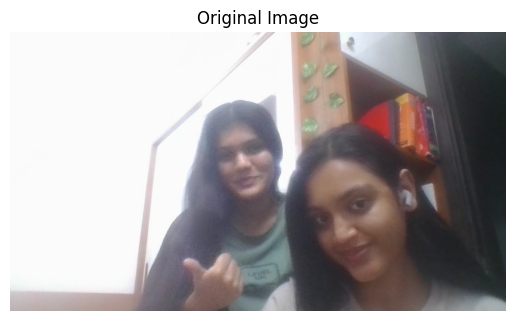

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

image = load_image(r"C:\Users\SANIKA CHAUDHARI\OneDrive\Documents\GitHub\BE_project\image.jpg")  # ← put your image path here
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")


Faces detected: 2


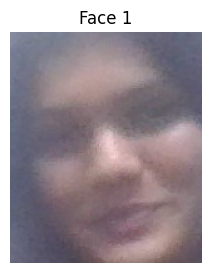

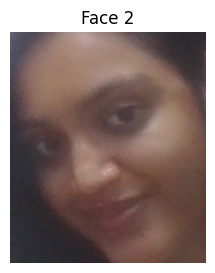

In [2]:
from mtcnn import MTCNN
def safe_crop(image, x, y, w, h):
    h_img, w_img, _ = image.shape

    x = max(0, x)
    y = max(0, y)
    w = min(w, w_img - x)
    h = min(h, h_img - y)

    if w <= 0 or h <= 0:
        return None

    return image[y:y+h, x:x+w]

detector = MTCNN()

def detect_and_crop_face(image):
    faces = detector.detect_faces(image)
    if len(faces) == 0:
        return None, None, None

    face_data = max(faces, key=lambda f: f['box'][2] * f['box'][3])
    x, y, w, h = face_data['box']
    landmarks = face_data['keypoints']

    face = safe_crop(image, x, y, w, h)
    if face is None:
        return None, None, None

    return face, landmarks, (x, y, w, h)


faces = detector.detect_faces(image)

print(f"Faces detected: {len(faces)}")

for i, face_data in enumerate(faces):
    x, y, w, h = face_data['box']
    face = image[y:y+h, x:x+w]

    plt.figure(figsize=(3,3))
    plt.imshow(face)
    plt.title(f"Face {i+1}")
    plt.axis("off")



In [3]:
def align_face(face, landmarks, box):
    x, y, _, _ = box

    left_eye = (
        landmarks['left_eye'][0] - x,
        landmarks['left_eye'][1] - y
    )
    right_eye = (
        landmarks['right_eye'][0] - x,
        landmarks['right_eye'][1] - y
    )

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    center = (face.shape[1] // 2, face.shape[0] // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    aligned = cv2.warpAffine(face, M, (face.shape[1], face.shape[0]))
    return aligned



In [4]:
def resize_and_normalize(aligned, size=224):
    face = cv2.resize(aligned, (size, size))
    face = face.astype(np.float32) / 255.0
    return face



In [5]:
def spatial_preprocess(face):
    # RGB normalized image
    faces= resize_and_normalize(face)
    return faces   # shape: (224,224,3)


In [6]:

def frequency_preprocess(face, size=224):
  

    face = resize_and_normalize(face)

    gray = cv2.cvtColor((face * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    gray = gray.astype(np.float32)

    dct = cv2.dct(gray)
    dct = np.log(np.abs(dct) + 1e-8)

    # ✅ Min–Max normalization
    dct = (dct - dct.min()) / (dct.max() - dct.min() + 1e-8)

    return dct[..., np.newaxis].astype(np.float32)
  # (224,224,1)



In [7]:
def run_preprocessing_multi(image_path):
    image = load_image(image_path)

    faces = detect_and_crop_faces(image)

    spatial_outputs = []
    freq_outputs = []
    meta = []

    for f in faces:
        face = f["face"]

        spatial_outputs.append(spatial_preprocess(face))
        freq_outputs.append(frequency_preprocess(face))
        meta.append({
            "box": f["box"],
            "landmarks": f["landmarks"]
        })

    if len(spatial_outputs) == 0:
        return None, None, None

    return (
        np.stack(spatial_outputs),
        np.stack(freq_outputs),
        meta
    )


In [9]:
spatial_out = spatial_preprocess(face)
freq_out = frequency_preprocess(face)


print("Spatial output:")
print("Shape:", spatial_out.shape)
print("Dtype:", spatial_out.dtype)
print("Min:", spatial_out.min(), "Max:", spatial_out.max())

print("\nFrequency output:")
print("Shape:", freq_out.shape)
print("Dtype:", freq_out.dtype)
print("Min:", freq_out.min(), "Max:", freq_out.max())


Spatial output:
Shape: (224, 224, 3)
Dtype: float32
Min: 0.13333334 Max: 0.80784315

Frequency output:
Shape: (224, 224, 1)
Dtype: float32
Min: 0.0 Max: 1.0


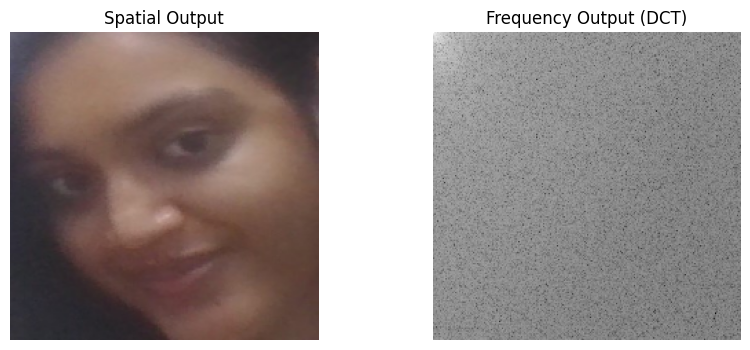

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].imshow(spatial_out)
axs[0].set_title("Spatial Output")
axs[0].axis("off")

axs[1].imshow(freq_out[:, :, 0], cmap="gray")
axs[1].set_title("Frequency Output (DCT)")
axs[1].axis("off")

plt.show()



